In [1]:
# 텐서 만들기
import torch

# (1) 초기화되지 않은 텐서
a = torch.empty(2, 3)
print("1️⃣ torch.empty(2,3)")
print(a, "\n")

# (2) 0으로 채워진 텐서
b = torch.zeros(2, 3)
print("2️⃣ torch.zeros(2,3)")
print(b, "\n")

# (3) 1로 채워진 텐서
c = torch.ones(2, 3)
print("3️⃣ torch.ones(2,3)")
print(c, "\n")

# (4) 정규분포를 따르는 난수 텐서
d = torch.randn(2, 3)
print("4️⃣ torch.randn(2,3)")
print(d, "\n")

# (5) 직접 값으로 텐서 생성
e = torch.tensor([1, 2, 3])
print("5️⃣ torch.tensor([1,2,3])")
print(e)


1️⃣ torch.empty(2,3)
tensor([[-5.4108e+08,  1.1659e-42,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00]]) 

2️⃣ torch.zeros(2,3)
tensor([[0., 0., 0.],
        [0., 0., 0.]]) 

3️⃣ torch.ones(2,3)
tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

4️⃣ torch.randn(2,3)
tensor([[ 0.5713, -0.0389, -0.2104],
        [ 0.3161, -0.3576, -1.0556]]) 

5️⃣ torch.tensor([1,2,3])
tensor([1, 2, 3])


```
출력값이
1️⃣ torch.empty(2,3)
tensor([[-5.4108e+08,  1.1659e-42,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00]]) 
         이렇게 안에 비어있는게 아니라 임의의 데이터로 채워져있는 이유.
         
torch.empty()는 “초기화하지 않은 텐서”야
torch.empty(2,3)는 말 그대로

“2×3 크기의 텐서를 만들되, 안에 있는 값을 초기화하지 않는다”
는 뜻이야.

🧠 즉, 어떤 일이 일어나냐면
PyTorch가 메모리 공간(=RAM 또는 GPU 메모리)을 확보함.
그런데 그 공간을 0으로 초기화하지 않음.
그 메모리 위치에는 이전에 다른 연산이나 프로그램이 썼던 값이 그대로 남아 있음.
그래서 결과가 이렇게 나오는 거야 👇

tensor([[-5.4108e+08,  1.1659e-42,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00]])


→ 쓰레기 값 (garbage value) 이라고 부르는 임의의 데이터가 들어 있는 거야.
```

##### 분산과 공분산에 대해서

##### PCA에 대해서
```
1️⃣ PCA란?
PCA(Principal Component Analysis, 주성분 분석)는
고차원 데이터를 저차원으로 압축하면서 중요한 정보를 최대한 보존하는 방법이에요.
목적:
데이터 차원 축소
시각화 용이
노이즈 제거
계산 효율 개선

쉽게 말하면, 데이터가 가진 “핵심 방향”을 찾아서 그 방향으로만 데이터를 재표현하는 방법이에요.

2️⃣ PCA가 하는 일
데이터의 **분산(variance)**이 가장 큰 방향을 찾는다.
데이터가 퍼져있는 방향이 가장 정보가 많다고 보기 때문이에요.
그 방향을 **주성분(Principal Component, PC)**이라고 부른다.
여러 주성분을 차례대로 찾아서 데이터의 구조를 요약한다.
PC1: 가장 큰 분산 방향
PC2: PC1과 직교하면서 두 번째로 큰 분산 방향
PC3: PC1, PC2와 직교하면서 세 번째로 큰 분산 방향

결국 원래 변수들을 선형 조합해서 새로운 축을 만드는 거예요.

3️⃣ PCA 계산 과정 (간단히)
데이터 정규화: 평균 0, 분산 1로 맞춤 (선택적)
공분산 행렬 계산: 변수들 간의 관계 확인
고유값과 고유벡터 계산:
고유벡터 = 주성분 방향
고유값 = 분산의 크기 (얼마나 중요한지)
데이터를 새로운 축으로 변환:
원래 데이터 × 고유벡터 = 주성분 점수(새로운 좌표)

4️⃣ 장점과 활용
차원 축소 → 시각화, 메모리 절약
노이즈 제거 → 중요한 패턴만 남김
머신러닝 성능 향상 → 불필요한 feature 제거
예시:
10차원 데이터를 2차원으로 줄여 시각화
이미지 압축, 얼굴 인식, 유전자 데이터 분석 등

5️⃣ PCA 시각화
PC1, PC2를 x축, y축으로 해서 점들을 그리면
데이터의 패턴, 군집, 이상치 등을 한눈에 볼 수 있음
```

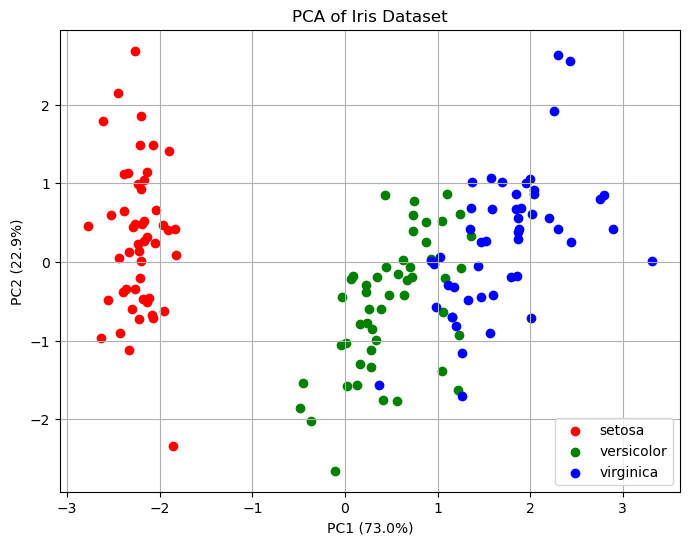

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1️⃣ 데이터 불러오기
iris = load_iris()
X = iris.data        # 4개의 feature
y = iris.target      # 0,1,2로 클래스 라벨
target_names = iris.target_names

# 2️⃣ 데이터 정규화 (PCA는 스케일에 민감)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3️⃣ PCA 적용 (차원 축소)
pca = PCA(n_components=2)  # 4D → 2D
X_pca = pca.fit_transform(X_scaled)

# 4️⃣ 결과를 DataFrame으로
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['target'] = y

# 5️⃣ 시각화
plt.figure(figsize=(8,6))
colors = ['r', 'g', 'b']

for i, color, name in zip([0,1,2], colors, target_names):
    plt.scatter(df_pca[df_pca['target']==i]['PC1'],
                df_pca[df_pca['target']==i]['PC2'],
                color=color, label=name)
    
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of Iris Dataset")
plt.legend()
plt.grid(True)
plt.show()
